# P2 - Mortgage Approval Prediction & Fair Lending Audit
## Notebook 2: Feature Engineering - Model Comparison - Error Analysis

**Approach:** Start simple (Decision Tree), add complexity (Random Forest), then use the best model (LightGBM). Cross-validate every model. End with error analysis - not just aggregate metrics but *who* the model gets wrong.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, f1_score, balanced_accuracy_score,
    classification_report, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.impute import SimpleImputer
import lightgbm as lgb
import shap

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
RANDOM_STATE = 42
print('Setup complete')

Setup complete


---
## 1. Load Clean Data

In [2]:
df = pd.read_parquet('../data/hmda_filtered.parquet')
print(f'Loaded: {df.shape}')
print(f'Approval rate: {df["approved"].mean():.1%} | Denial rate: {1-df["approved"].mean():.1%}')

Loaded: (196113, 95)
Approval rate: 87.8% | Denial rate: 12.2%


---
## 2. Feature Engineering

10 domain features, all derived from pre-decision information only (no leakage).

In [3]:
# Numeric coercion for base columns
for col in ['income', 'loan_amount_k', 'property_value_k', 'loan_to_value_ratio',
            'loan_term', 'tract_to_msa_income_percentage', 'tract_minority_population_percent']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Feature 1: Loan-to-income ratio (already computed in notebook 1, verify)
if 'loan_to_income_ratio' not in df.columns:
    df['loan_to_income_ratio'] = df['loan_amount_k'] / df['income']

# Feature 2: dti_missing_flag (already in parquet from notebook 1)
if 'dti_missing_flag' not in df.columns:
    df['dti_missing_flag'] = df['dti_numeric'].isnull().astype(int)

# Feature 3: High DTI flag (>43% - standard QM threshold)
df['high_dti_flag'] = (df['dti_numeric'] > 43).astype(int)

# Feature 4: High LTV flag (>80% - PMI threshold)
df['high_ltv_flag'] = (df['loan_to_value_ratio'] > 80).astype(int)

# Feature 5: Low income tract (<80% of MSA median)
if 'tract_to_msa_income_percentage' in df.columns:
    df['low_income_tract_flag'] = (df['tract_to_msa_income_percentage'] < 80).astype(int)

# Feature 6: Minority majority tract (>50% minority population)
if 'tract_minority_population_percent' in df.columns:
    df['minority_tract_flag'] = (df['tract_minority_population_percent'] > 50).astype(int)

# Feature 7: Rate spread flag removed (leakage) - use conforming flag instead
df['non_conforming_flag'] = (df['conforming_loan_limit'] == 'NC').astype(int)

# Feature 8: Co-applicant present
if 'co-applicant_sex' in df.columns:
    df['co_applicant_present'] = (~df['co-applicant_sex'].isin([5, '5'])).astype(int)
elif 'co_applicant_sex' in df.columns:
    df['co_applicant_present'] = (~df['co_applicant_sex'].isin([5, '5'])).astype(int)

# Feature 9: County mean approval rate (target encoding - uses full dataset for EDA, CV-safe version for model)
county_col = 'county_code'
if county_col in df.columns:
    county_rate = df.groupby(county_col)['approved'].mean()
    df['county_approval_rate'] = df[county_col].map(county_rate)

# Feature 10: Investment/second home flag
df['non_primary_flag'] = (df['occupancy_type'] != 1).astype(int)

# Feature 11: Age group - bin applicant_age into standard underwriting bands
# HMDA stores age as string ranges: <25, 25-34, 35-44, 45-54, 55-64, 65-74, >74, 8888 (not provided)
if 'applicant_age' in df.columns:
    age_map = {
        '<25': 0, '25-34': 1, '35-44': 2,
        '45-54': 3, '55-64': 4, '65-74': 5, '>74': 6,
        '8888': np.nan  # not provided
    }
    df['applicant_age_enc'] = df['applicant_age'].astype(str).map(age_map)
    print('applicant_age distribution:')
    print(df['applicant_age'].value_counts().to_string())
    print('\nDenial rate by age group:')
    age_denial = df.groupby('applicant_age')['approved'].agg(['mean','count'])
    age_denial['denial_rate'] = 1 - age_denial['mean']
    print(age_denial.sort_values('denial_rate', ascending=False).to_string())

engineered = ['loan_to_income_ratio', 'dti_missing_flag', 'high_dti_flag', 'high_ltv_flag',
              'low_income_tract_flag', 'minority_tract_flag', 'non_conforming_flag',
              'co_applicant_present', 'county_approval_rate', 'non_primary_flag',
              'applicant_age_enc']
engineered = [f for f in engineered if f in df.columns]
print(f'\nEngineered features ({len(engineered)}): {engineered}')

applicant_age distribution:
applicant_age
35-44    61592
25-34    53860
45-54    37034
55-64    24118
65-74    11375
<25       4522
>74       3587
8888        25

Denial rate by age group:
                mean  count  denial_rate
applicant_age                           
8888          0.7200     25       0.2800
<25           0.7979   4522       0.2021
>74           0.8447   3587       0.1553
55-64         0.8538  24118       0.1462
65-74         0.8605  11375       0.1395
45-54         0.8682  37034       0.1318
35-44         0.8899  61592       0.1101
25-34         0.8955  53860       0.1045

Engineered features (11): ['loan_to_income_ratio', 'dti_missing_flag', 'high_dti_flag', 'high_ltv_flag', 'low_income_tract_flag', 'minority_tract_flag', 'non_conforming_flag', 'co_applicant_present', 'county_approval_rate', 'non_primary_flag', 'applicant_age_enc']


In [4]:
# Verify engineered features look sensible
print('Engineered feature summary:')
print(df[engineered].describe().T[['mean','std','min','max']].to_string())

# Check denial rate for high_dti_flag and high_ltv_flag - should be higher than baseline
baseline = 1 - df['approved'].mean()
for flag in ['high_dti_flag', 'high_ltv_flag', 'dti_missing_flag', 'non_conforming_flag']:
    if flag in df.columns:
        dr_flag   = 1 - df[df[flag]==1]['approved'].mean()
        dr_noflag = 1 - df[df[flag]==0]['approved'].mean()
        print(f'{flag}=1: denial {dr_flag:.1%} | =0: denial {dr_noflag:.1%} | baseline: {baseline:.1%}')

Engineered feature summary:
                        mean     std    min       max
loan_to_income_ratio  3.5566 12.2642 0.0211 2175.0000
dti_missing_flag      0.0156  0.1240 0.0000    1.0000
high_dti_flag         0.4003  0.4900 0.0000    1.0000
high_ltv_flag         0.3069  0.4612 0.0000    1.0000
low_income_tract_flag 0.1982  0.3987 0.0000    1.0000
minority_tract_flag   0.5780  0.4939 0.0000    1.0000
non_conforming_flag   0.1369  0.3437 0.0000    1.0000
co_applicant_present  0.5276  0.4992 0.0000    1.0000
county_approval_rate  0.8785  0.0245 0.7786    0.9565
non_primary_flag      0.1042  0.3055 0.0000    1.0000
applicant_age_enc     2.3613  1.3161 0.0000    6.0000


high_dti_flag=1: denial 19.9% | =0: denial 7.0% | baseline: 12.2%


high_ltv_flag=1: denial 11.4% | =0: denial 12.5% | baseline: 12.2%
dti_missing_flag=1: denial 21.7% | =0: denial 12.0% | baseline: 12.2%


non_conforming_flag=1: denial 11.1% | =0: denial 12.4% | baseline: 12.2%


In [5]:
# Label encode categoricals
cat_cols = ['derived_race', 'derived_ethnicity', 'derived_sex',
            'loan_type', 'loan_purpose', 'lien_status', 'occupancy_type']
cat_cols = [c for c in cat_cols if c in df.columns]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f'{col}: {le.classes_.tolist()}')

derived_race: ['2 or more minority races', 'American Indian or Alaska Native', 'Asian', 'Black or African American', 'Free Form Text Only', 'Joint', 'Native Hawaiian or Other Pacific Islander', 'Race Not Available', 'White']
derived_ethnicity: ['Ethnicity Not Available', 'Free Form Text Only', 'Hispanic or Latino', 'Joint', 'Not Hispanic or Latino']


derived_sex: ['Female', 'Joint', 'Male', 'Sex Not Available']
loan_type: ['1']
loan_purpose: ['1']


lien_status: ['1']


occupancy_type: ['1', '2', '3']


In [6]:
# Final feature list - NO leakage columns
base_feats = ['income', 'loan_amount_k', 'property_value_k', 'loan_to_value_ratio',
              'dti_numeric', 'loan_term',
              'derived_race_enc', 'derived_ethnicity_enc', 'derived_sex_enc',
              'loan_type_enc', 'occupancy_type_enc']

all_features = list(dict.fromkeys(base_feats + engineered))
all_features = [f for f in all_features if f in df.columns]
# Remove any raw categoricals that were encoded
all_features = [f for f in all_features if f not in cat_cols]

# Features without demographics (for fair lending audit comparison)
demo_feats = ['derived_race_enc', 'derived_ethnicity_enc', 'derived_sex_enc']
all_features_nodemo = [f for f in all_features if f not in demo_feats]

print(f'Full feature set ({len(all_features)}):')
for f in all_features:
    tag = ' *' if f in demo_feats else ''
    print(f'  {f}{tag}')
print(f'\n* = demographic features (excluded in fair model)')
print(f'\nFair feature set (no demographics): {len(all_features_nodemo)} features')

Full feature set (22):
  income
  loan_amount_k
  property_value_k
  loan_to_value_ratio
  dti_numeric
  loan_term
  derived_race_enc *
  derived_ethnicity_enc *
  derived_sex_enc *
  loan_type_enc
  occupancy_type_enc
  loan_to_income_ratio
  dti_missing_flag
  high_dti_flag
  high_ltv_flag
  low_income_tract_flag
  minority_tract_flag
  non_conforming_flag
  co_applicant_present
  county_approval_rate
  non_primary_flag
  applicant_age_enc

* = demographic features (excluded in fair model)

Fair feature set (no demographics): 19 features


---
## 3. Train/Test Split

In [7]:
X = df[all_features].apply(pd.to_numeric, errors='coerce')
y = df['approved']

# Save demographic series aligned to original index (needed for fairness analysis)
demo_race = df['derived_race']
demo_eth  = df['derived_ethnicity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

race_test = demo_race.loc[X_test.index]
eth_test  = demo_eth.loc[X_test.index]

# Impute missing values (median strategy)
imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=all_features, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=all_features, index=X_test.index)

print(f'Train: {X_train_imp.shape} | Test: {X_test_imp.shape}')
print(f'Train denial: {1-y_train.mean():.1%} | Test denial: {1-y_test.mean():.1%}')

Train: (156890, 22) | Test: (39223, 22)
Train denial: 12.2% | Test denial: 12.2%


---
## 4. Model 1 - Decision Tree (Start Simple)

Why start here: interpretable, no hyperparameter complexity, shows what a single set of splits can learn. A low-depth tree is also a useful sanity check - if a depth-3 tree achieves 80%+ AUC, the signal is real.

In [8]:
# Decision tree - try multiple depths to understand underfitting vs overfitting
dt_results = []
for depth in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=depth, class_weight='balanced', random_state=RANDOM_STATE)
    cv_scores = cross_val_score(dt, X_train_imp, y_train, cv=5, scoring='roc_auc',
                                 n_jobs=-1)
    dt.fit(X_train_imp, y_train)
    test_auc = roc_auc_score(y_test, dt.predict_proba(X_test_imp)[:,1])
    dt_results.append({
        'max_depth': str(depth),
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'test_auc': test_auc
    })
    print(f'depth={str(depth):4s}  CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}  Test AUC={test_auc:.4f}')

dt_df = pd.DataFrame(dt_results)

depth=3     CV AUC=0.7735 ± 0.0028  Test AUC=0.7769


depth=5     CV AUC=0.7894 ± 0.0080  Test AUC=0.7978


depth=7     CV AUC=0.7999 ± 0.0050  Test AUC=0.8052


depth=10    CV AUC=0.7998 ± 0.0058  Test AUC=0.8015


depth=None  CV AUC=0.6901 ± 0.0058  Test AUC=0.6915


In [9]:
# Best decision tree: depth=5 (balances interpretability vs performance)
best_dt_depth = 5
dt_best = DecisionTreeClassifier(max_depth=best_dt_depth, class_weight='balanced', random_state=RANDOM_STATE)
dt_best.fit(X_train_imp, y_train)
dt_proba = dt_best.predict_proba(X_test_imp)[:,1]
dt_auc = roc_auc_score(y_test, dt_proba)

# Optimal threshold
thresholds = np.arange(0.05, 0.95, 0.01)
f1s = [f1_score(y_test, (dt_proba>=t).astype(int), zero_division=0) for t in thresholds]
dt_threshold = thresholds[np.argmax(f1s)]
dt_pred = (dt_proba >= dt_threshold).astype(int)

print(f'Decision Tree (depth={best_dt_depth})')
print(f'  AUC-ROC:          {dt_auc:.4f}')
print(f'  Optimal threshold:{dt_threshold:.2f}')
print(f'  F1:               {f1_score(y_test, dt_pred):.4f}')
print(f'  Balanced acc:     {balanced_accuracy_score(y_test, dt_pred):.4f}')
print(f'\nTop split features (feature importances):')
feat_imp_dt = pd.Series(dt_best.feature_importances_, index=all_features).sort_values(ascending=False)
print(feat_imp_dt.head(8).to_string())

Decision Tree (depth=5)
  AUC-ROC:          0.7978
  Optimal threshold:0.11
  F1:               0.9528
  Balanced acc:     0.6836

Top split features (feature importances):
dti_numeric            0.7377
loan_term              0.1628
dti_missing_flag       0.0293
property_value_k       0.0258
loan_to_value_ratio    0.0240
co_applicant_present   0.0104
loan_to_income_ratio   0.0061
county_approval_rate   0.0012


In [10]:
# Show the actual top-3 decision rules - what does the tree actually learn?
tree_rules = export_text(dt_best, feature_names=all_features, max_depth=3)
print('Decision Tree top rules (depth 3):')
print(tree_rules[:2000])

Decision Tree top rules (depth 3):
|--- dti_numeric <= 52.00
|   |--- loan_term <= 352.50
|   |   |--- property_value_k <= 420.00
|   |   |   |--- loan_to_value_ratio <= 75.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- loan_to_value_ratio >  75.27
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- property_value_k >  420.00
|   |   |   |--- loan_term <= 245.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- loan_term >  245.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- loan_term >  352.50
|   |   |--- dti_missing_flag <= 0.50
|   |   |   |--- loan_to_value_ratio <= 95.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- loan_to_value_ratio >  95.01
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- dti_missing_flag >  0.50
|   |   |   |--- loan_to_income_ratio <= 4.29
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- loan_to_income_ratio >  4.29
|   |   |   |   |--- truncated b

---
## 5. Model 2 - Random Forest

Why: reduces DT variance via bagging + feature subsampling. Should substantially improve AUC. Cross-validate to check.

In [11]:
# Random forest - try a few n_estimators to see where gains plateau
rf_results = []
for n in [50, 100, 200]:
    rf = RandomForestClassifier(n_estimators=n, max_depth=15, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
    cv_scores = cross_val_score(rf, X_train_imp, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    rf.fit(X_train_imp, y_train)
    test_auc = roc_auc_score(y_test, rf.predict_proba(X_test_imp)[:,1])
    rf_results.append({'n_estimators': n, 'cv_auc_mean': cv_scores.mean(),
                       'cv_auc_std': cv_scores.std(), 'test_auc': test_auc})
    print(f'n={n:3d}  CV AUC={cv_scores.mean():.4f} ± {cv_scores.std():.4f}  Test AUC={test_auc:.4f}')

n= 50  CV AUC=0.8201 ± 0.0035  Test AUC=0.8267


n=100  CV AUC=0.8224 ± 0.0035  Test AUC=0.8300


n=200  CV AUC=0.8237 ± 0.0031  Test AUC=0.8310


In [12]:
# Best RF: 100 trees (gains plateau quickly)
rf_best = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)
rf_best.fit(X_train_imp, y_train)
rf_proba = rf_best.predict_proba(X_test_imp)[:,1]
rf_auc = roc_auc_score(y_test, rf_proba)

f1s_rf = [f1_score(y_test, (rf_proba>=t).astype(int), zero_division=0) for t in thresholds]
rf_threshold = thresholds[np.argmax(f1s_rf)]
rf_pred = (rf_proba >= rf_threshold).astype(int)

print(f'Random Forest (n=100, depth=15)')
print(f'  AUC-ROC:          {rf_auc:.4f}')
print(f'  Optimal threshold:{rf_threshold:.2f}')
print(f'  F1:               {f1_score(y_test, rf_pred):.4f}')
print(f'  Balanced acc:     {balanced_accuracy_score(y_test, rf_pred):.4f}')
print(f'\nTop features:')
feat_imp_rf = pd.Series(rf_best.feature_importances_, index=all_features).sort_values(ascending=False)
print(feat_imp_rf.head(8).to_string())

Random Forest (n=100, depth=15)
  AUC-ROC:          0.8300
  Optimal threshold:0.27
  F1:               0.9534
  Balanced acc:     0.7142

Top features:
dti_numeric            0.3358
property_value_k       0.1067
loan_term              0.0942
loan_to_income_ratio   0.0836
income                 0.0692
loan_amount_k          0.0645
loan_to_value_ratio    0.0526
high_dti_flag          0.0472


---
## 6. Model 3 - LightGBM

Why: leaf-wise tree growth, faster on 200K rows, handles imbalanced classes natively, best-in-class for tabular financial data.

In [13]:
scale_pos_weight = y_train.sum() / (y_train == 0).sum()
print(f'scale_pos_weight (approved/denied): {scale_pos_weight:.2f}')

lgb_model = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.05, num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    reg_alpha=0.1, reg_lambda=0.1,
    n_estimators=500, random_state=RANDOM_STATE, verbose=-1
)

# 5-fold cross-validation
cv_lgb = cross_val_score(lgb_model, X_train_imp, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'LightGBM 5-fold CV AUC: {cv_lgb.mean():.4f} ± {cv_lgb.std():.4f}')

# Fit with early stopping on holdout
lgb_model.fit(
    X_train_imp, y_train,
    eval_set=[(X_test_imp, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

lgb_proba = lgb_model.predict_proba(X_test_imp)[:,1]
lgb_auc   = roc_auc_score(y_test, lgb_proba)

f1s_lgb = [f1_score(y_test, (lgb_proba>=t).astype(int), zero_division=0) for t in thresholds]
lgb_threshold = thresholds[np.argmax(f1s_lgb)]
lgb_pred = (lgb_proba >= lgb_threshold).astype(int)

print(f'\nLightGBM Test Results')
print(f'  AUC-ROC:          {lgb_auc:.4f}')
print(f'  Optimal threshold:{lgb_threshold:.2f}')
print(f'  F1:               {f1_score(y_test, lgb_pred):.4f}')
print(f'  Balanced acc:     {balanced_accuracy_score(y_test, lgb_pred):.4f}')

scale_pos_weight (approved/denied): 7.21


LightGBM 5-fold CV AUC: 0.8401 ± 0.0032


  File "C:\Users\nisarg\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\nisarg\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nisarg\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nisarg\anaconda3\Lib\subproc


LightGBM Test Results
  AUC-ROC:          0.8490
  Optimal threshold:0.85
  F1:               0.9581
  Balanced acc:     0.7255


---
## 7. Model Comparison

Model Comparison:
                  Model  Test AUC     F1  Balanced Acc
Decision Tree (depth=5)    0.7978 0.9528        0.6836
  Random Forest (n=100)    0.8300 0.9534        0.7142
               LightGBM    0.8490 0.9581        0.7255


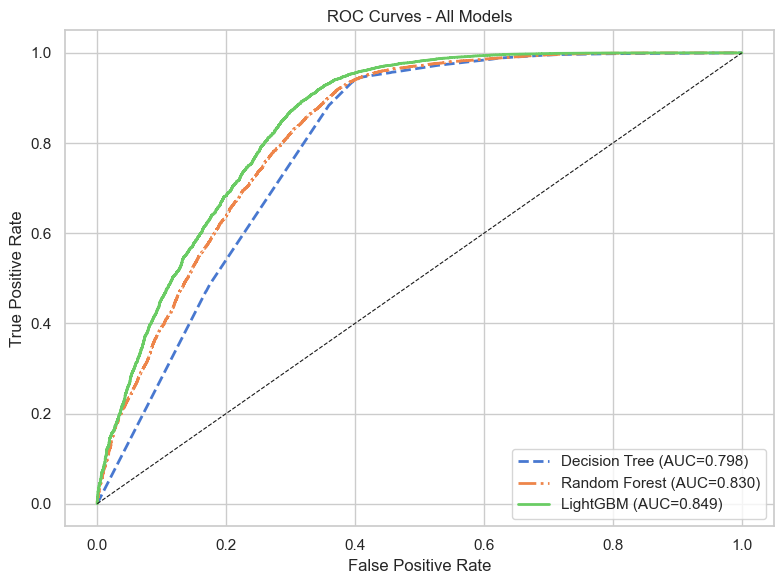

In [14]:
model_comparison = pd.DataFrame([
    {'Model': 'Decision Tree (depth=5)',     'Test AUC': dt_auc,
     'F1': f1_score(y_test, dt_pred), 'Balanced Acc': balanced_accuracy_score(y_test, dt_pred)},
    {'Model': 'Random Forest (n=100)',       'Test AUC': rf_auc,
     'F1': f1_score(y_test, rf_pred), 'Balanced Acc': balanced_accuracy_score(y_test, rf_pred)},
    {'Model': 'LightGBM',                   'Test AUC': lgb_auc,
     'F1': f1_score(y_test, lgb_pred), 'Balanced Acc': balanced_accuracy_score(y_test, lgb_pred)},
])
print('Model Comparison:')
print(model_comparison.to_string(index=False))

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
for proba, label, ls in [
    (dt_proba,  f'Decision Tree (AUC={dt_auc:.3f})',  '--'),
    (rf_proba,  f'Random Forest (AUC={rf_auc:.3f})',  '-.'),
    (lgb_proba, f'LightGBM (AUC={lgb_auc:.3f})',      '-'),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=label, linewidth=2, linestyle=ls)
ax.plot([0,1],[0,1],'k--', linewidth=0.8)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - All Models')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/roc_comparison.png', dpi=150)
plt.show()

---
## 8. SHAP Explainability (LightGBM)

In [15]:
shap_n = min(5000, len(X_test_imp))
X_shap = X_test_imp.sample(shap_n, random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_shap)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

print(f'SHAP computed on {shap_n} test samples')

SHAP computed on 5000 test samples


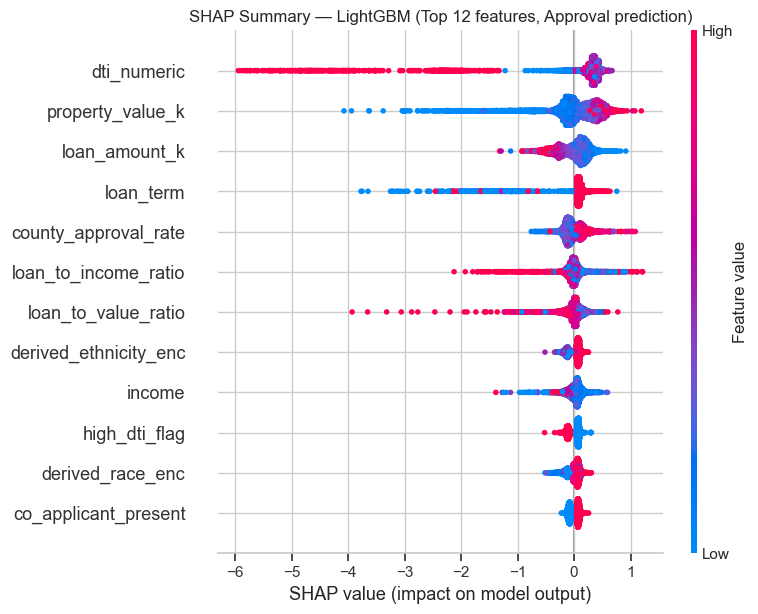

In [16]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, max_display=12, show=False)
plt.title('SHAP Summary - LightGBM (Top 12 features, Approval prediction)')
plt.tight_layout()
plt.savefig('../outputs/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns).sort_values(ascending=False)
print('Feature importance by mean |SHAP| value:')
print(mean_shap.head(12).to_string())

top_feature = mean_shap.index[0]

demo_enc = [c for c in mean_shap.index[:10] if any(d in c for d in ['race','ethnicity','sex'])]
if demo_enc:
    print(f'\nDemographic features in top 10: {demo_enc}')
    print('  -> model is using race/sex as predictors - document this finding')
else:
    print('\nNo demographic features in top 10 - model relies on financial variables')

Feature importance by mean |SHAP| value:
dti_numeric             0.5822
property_value_k        0.3254
loan_amount_k           0.2073
loan_term               0.1854
county_approval_rate    0.1270
loan_to_income_ratio    0.1078
loan_to_value_ratio     0.1073
derived_ethnicity_enc   0.0939
income                  0.0916
high_dti_flag           0.0902
derived_race_enc        0.0822
co_applicant_present    0.0799

Demographic features in top 10: ['derived_ethnicity_enc']
  -> model is using race/sex as predictors - document this finding


---
## 9. Error Analysis - Who Does the Model Get Wrong?

Aggregate metrics hide important failures. This section looks at **false negatives** (applicants who would have been approved but the model denied) and **false positives** (applicants the model approved but were actually denied) broken down by demographic group.

In [18]:
error_df = pd.DataFrame({
    'actual':    y_test.values,
    'predicted': lgb_pred,
    'proba':     lgb_proba,
    'race':      race_test.values,
    'ethnicity': eth_test.values,
}, index=y_test.index)

error_df['error_type'] = 'Correct'
error_df.loc[(error_df['actual']==1) & (error_df['predicted']==0), 'error_type'] = 'False Negative (model denied, should approve)'
error_df.loc[(error_df['actual']==0) & (error_df['predicted']==1), 'error_type'] = 'False Positive (model approved, should deny)'

print('Error type counts:')
print(error_df['error_type'].value_counts())
fn_rate = (error_df['error_type'] == 'False Negative (model denied, should approve)').mean()
fp_rate = (error_df['error_type'] == 'False Positive (model approved, should deny)').mean()
print(f'\nFalse Negative rate (harmful - wrongly denied): {fn_rate:.2%}')
print(f'False Positive rate (risky - wrongly approved): {fp_rate:.2%}')

Error type counts:
error_type
Correct                                          36246
False Positive (model approved, should deny)      2565
False Negative (model denied, should approve)      412
Name: count, dtype: int64

False Negative rate (harmful - wrongly denied): 1.05%
False Positive rate (risky - wrongly approved): 6.54%


False Negative rate by race (among applicants who SHOULD be approved):
                                     race  false_negative_rate  n_actual_approved
                Black or African American               0.0352                739
                 2 or more minority races               0.0263                 76
         American Indian or Alaska Native               0.0194                155
                       Race Not Available               0.0125               7501
                                    White               0.0124              16493
                                    Asian               0.0089               7982
                                    Joint               0.0078               1415
Native Hawaiian or Other Pacific Islander               0.0000                 73


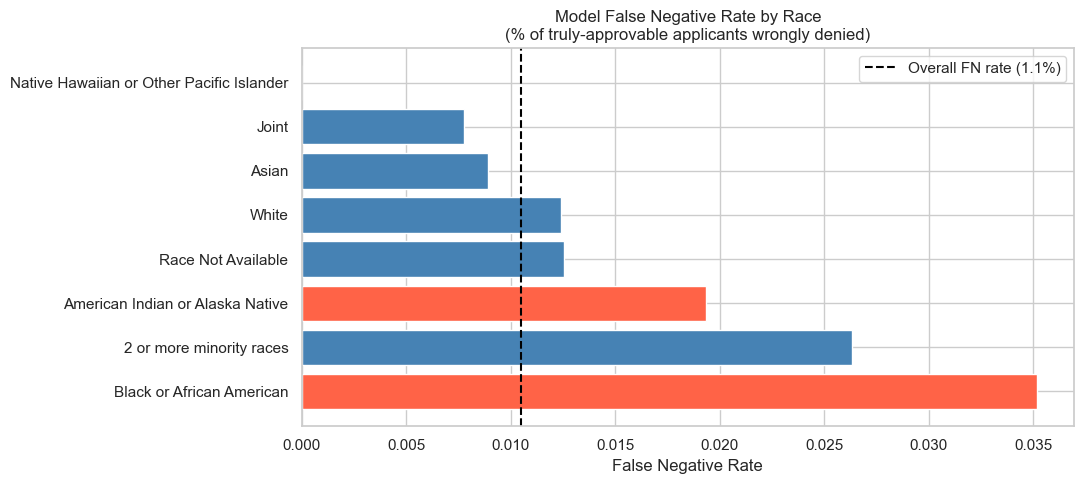

In [19]:
# False Negative rate by race - which group is most likely to be wrongly denied by the model?
fn_by_race = (
    error_df[error_df['actual'] == 1]  # only look at applicants who should be approved
    .groupby('race')
    .apply(lambda x: (x['predicted'] == 0).mean())
    .rename('false_negative_rate')
    .reset_index()
)
fn_by_race['n_actual_approved'] = (
    error_df[error_df['actual']==1].groupby('race').size().values
)
fn_by_race = fn_by_race[fn_by_race['n_actual_approved'] >= 50].sort_values('false_negative_rate', ascending=False)

print('False Negative rate by race (among applicants who SHOULD be approved):')
print(fn_by_race.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['tomato' if r in ['Black or African American','Native Hawaiian or Other Pacific Islander','American Indian or Alaska Native']
          else 'steelblue' for r in fn_by_race['race']]
ax.barh(fn_by_race['race'], fn_by_race['false_negative_rate'], color=colors)
fn_baseline = (error_df['actual']==1).mean() - (error_df[(error_df['actual']==1)]['predicted']).mean()
ax.axvline(fn_rate, color='black', linestyle='--', label=f'Overall FN rate ({fn_rate:.1%})')
ax.set_xlabel('False Negative Rate')
ax.set_title('Model False Negative Rate by Race\n(% of truly-approvable applicants wrongly denied)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/false_negative_by_race.png', dpi=150)
plt.show()

In [20]:
# Model approval rate vs actual approval rate by race - does the model amplify or reduce the gap?
race_fairness = (
    error_df.groupby('race')
    .agg(n=('actual','count'),
         actual_approval_rate=('actual','mean'),
         model_approval_rate=('predicted','mean'))
)
race_fairness['actual_denial_rate'] = 1 - race_fairness['actual_approval_rate']
race_fairness['model_denial_rate']  = 1 - race_fairness['model_approval_rate']

ref = 'White'
if ref in race_fairness.index:
    ref_actual = race_fairness.loc[ref, 'actual_approval_rate']
    ref_model  = race_fairness.loc[ref, 'model_approval_rate']
    race_fairness['actual_AIR'] = race_fairness['actual_approval_rate'] / ref_actual
    race_fairness['model_AIR']  = race_fairness['model_approval_rate']  / ref_model
    race_fairness['AIR_change'] = race_fairness['model_AIR'] - race_fairness['actual_AIR']

print('Actual vs model AIR by race (positive AIR_change = model is FAIRER than raw data):')
cols_show = ['n','actual_denial_rate','model_denial_rate','actual_AIR','model_AIR','AIR_change']
cols_show = [c for c in cols_show if c in race_fairness.columns]
print(race_fairness[race_fairness['n'] >= 50][cols_show].sort_values('actual_AIR').to_string())

Actual vs model AIR by race (positive AIR_change = model is FAIRER than raw data):
                                               n  actual_denial_rate  model_denial_rate  actual_AIR  model_AIR  AIR_change
race                                                                                                                      
Native Hawaiian or Other Pacific Islander    101              0.2772             0.1980      0.8186     0.8578      0.0392
Black or African American                    910              0.1879             0.1264      0.9197     0.9344      0.0147
American Indian or Alaska Native             190              0.1842             0.1316      0.9239     0.9288      0.0049
2 or more minority races                      91              0.1648             0.0989      0.9459     0.9638      0.0179
Race Not Available                          8879              0.1552             0.0907      0.9568     0.9726      0.0158
White                                      18679        

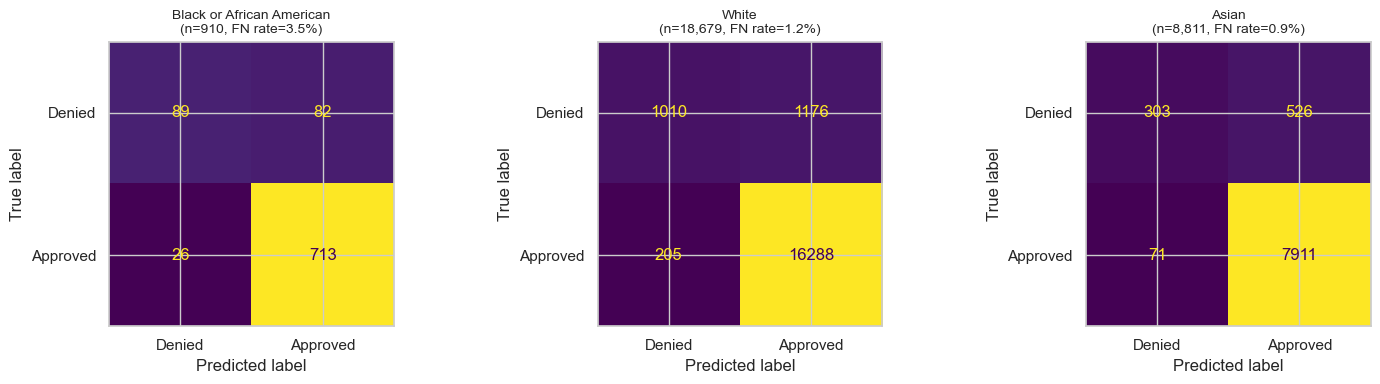

In [21]:
# Confusion matrices side-by-side for Black vs White applicants
groups_cm = {
    'Black or African American': error_df[error_df['race'] == 'Black or African American'],
    'White':                      error_df[error_df['race'] == 'White'],
    'Asian':                      error_df[error_df['race'] == 'Asian'],
}
groups_cm = {k: v for k, v in groups_cm.items() if len(v) >= 50}

fig, axes = plt.subplots(1, len(groups_cm), figsize=(5*len(groups_cm), 4))
if len(groups_cm) == 1:
    axes = [axes]
for ax, (grp, sub) in zip(axes, groups_cm.items()):
    cm = confusion_matrix(sub['actual'], sub['predicted'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Denied','Approved'])
    disp.plot(ax=ax, colorbar=False)
    acc = (sub['actual'] == sub['predicted']).mean()
    fn_g = (sub[(sub['actual']==1)]['predicted']==0).mean()
    ax.set_title(f'{grp}\n(n={len(sub):,}, FN rate={fn_g:.1%})', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix_by_race.png', dpi=150)
plt.show()

---
## 10. Fairness: Threshold Analysis

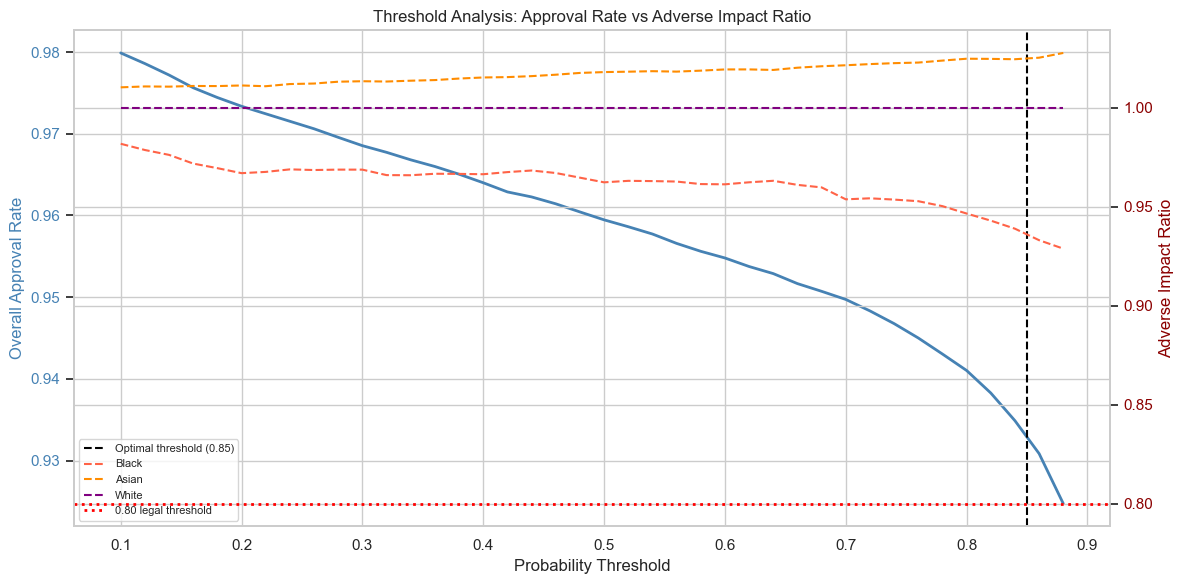

In [22]:
threshold_range = np.arange(0.10, 0.90, 0.02)
results = []
target_groups = ['Black or African American', 'Hispanic or Latino', 'Asian', 'White']

for t in threshold_range:
    preds = (lgb_proba >= t).astype(int)
    row = {'threshold': t, 'overall_approval_rate': preds.mean()}
    ref_r = preds[race_test.values == 'White'].mean()
    if ref_r > 0:
        for grp in target_groups:
            mask = race_test.values == grp
            if mask.sum() >= 50:
                row[f'AIR_{grp.split()[0]}'] = preds[mask].mean() / ref_r
    results.append(row)

thr_df = pd.DataFrame(results)
air_cols = [c for c in thr_df.columns if c.startswith('AIR_')]

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Probability Threshold')
ax1.set_ylabel('Overall Approval Rate', color='steelblue')
ax1.plot(thr_df['threshold'], thr_df['overall_approval_rate'], color='steelblue', linewidth=2)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.set_ylabel('Adverse Impact Ratio', color='darkred')
palette = ['tomato','darkorange','purple','green']
for col, clr in zip(air_cols, palette):
    ax2.plot(thr_df['threshold'], thr_df[col], color=clr, linestyle='--',
             linewidth=1.5, label=col.replace('AIR_',''))
ax2.axhline(0.80, color='red', linestyle=':', linewidth=2, label='0.80 legal threshold')
ax2.tick_params(axis='y', labelcolor='darkred')
ax1.axvline(lgb_threshold, color='black', linestyle='--', linewidth=1.5,
            label=f'Optimal threshold ({lgb_threshold:.2f})')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left', fontsize=8)
ax1.set_title('Threshold Analysis: Approval Rate vs Adverse Impact Ratio')
plt.tight_layout()
plt.savefig('../outputs/threshold_tradeoff.png', dpi=150)
plt.show()

---
## 11. Final Summary

In [23]:
print('='*65)
print('MODEL COMPARISON SUMMARY')
print('='*65)
print(model_comparison.to_string(index=False))

print('\n' + '='*65)
print('FINAL MODEL (LightGBM) METRICS')
print('='*65)
print(f'Dataset:              {len(df):,} applications')
print(f'Engineered features:  {len(engineered)}')
print(f'Total model features: {len(all_features)}')
print(f'AUC-ROC:              {lgb_auc:.4f}')
print(f'CV AUC (5-fold):      {cv_lgb.mean():.4f} +/- {cv_lgb.std():.4f}')
print(f'Optimal threshold:    {lgb_threshold:.2f}')
print(f'F1 at threshold:      {f1_score(y_test, lgb_pred):.4f}')
print(f'Balanced accuracy:    {balanced_accuracy_score(y_test, lgb_pred):.4f}')
print(f'Top SHAP feature:     {top_feature}')

print('\n' + '='*65)
print('ERROR ANALYSIS')
print('='*65)
print(f'Overall False Negative rate: {fn_rate:.2%}')
print('False Negative rate by race:')
print(fn_by_race[['race','false_negative_rate','n_actual_approved']].to_string(index=False))

print('\n' + '='*65)
print('FAIRNESS AT OPTIMAL THRESHOLD')
print('='*65)
row_opt = thr_df.iloc[(thr_df['threshold'] - lgb_threshold).abs().argsort()[:1]]
print(f'Overall approval rate: {row_opt["overall_approval_rate"].values[0]:.1%}')
for col in air_cols:
    v = row_opt[col].values[0]
    flag = ' <- BELOW 0.80' if v < 0.80 else ''
    print(f'  {col}: {v:.3f}{flag}')

MODEL COMPARISON SUMMARY
                  Model  Test AUC     F1  Balanced Acc
Decision Tree (depth=5)    0.7978 0.9528        0.6836
  Random Forest (n=100)    0.8300 0.9534        0.7142
               LightGBM    0.8490 0.9581        0.7255

FINAL MODEL (LightGBM) METRICS
Dataset:              196,113 applications
Engineered features:  11
Total model features: 22
AUC-ROC:              0.8490
CV AUC (5-fold):      0.8401 +/- 0.0032
Optimal threshold:    0.85
F1 at threshold:      0.9581
Balanced accuracy:    0.7255
Top SHAP feature:     dti_numeric

ERROR ANALYSIS
Overall False Negative rate: 1.05%
False Negative rate by race:
                                     race  false_negative_rate  n_actual_approved
                Black or African American               0.0352                739
                 2 or more minority races               0.0263                 76
         American Indian or Alaska Native               0.0194                155
                       Race Not Av

---
## 12. Fair Lending Audit - Model With vs Without Demographics

A compliant lending model cannot use race, ethnicity, or sex as inputs. This section builds a second LightGBM using only financial and geographic features, then compares its AIR to the full model.

Key question: does removing demographics improve or worsen fairness?

In [24]:
# Build fair model - same LightGBM config, no demographic features
X_train_nd = X_train_imp[all_features_nodemo]
X_test_nd  = X_test_imp[all_features_nodemo]

lgb_fair = lgb.LGBMClassifier(
    objective='binary', metric='auc',
    scale_pos_weight=scale_pos_weight,
    learning_rate=0.05, num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
    reg_alpha=0.1, reg_lambda=0.1,
    n_estimators=500, random_state=RANDOM_STATE, verbose=-1
)

cv_fair = cross_val_score(lgb_fair, X_train_nd, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
lgb_fair.fit(
    X_train_nd, y_train,
    eval_set=[(X_test_nd, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

fair_proba = lgb_fair.predict_proba(X_test_nd)[:,1]
fair_auc   = roc_auc_score(y_test, fair_proba)

f1s_fair = [f1_score(y_test, (fair_proba>=t).astype(int), zero_division=0) for t in thresholds]
fair_threshold = thresholds[np.argmax(f1s_fair)]
fair_pred = (fair_proba >= fair_threshold).astype(int)

print('Fair Model (no demographics)')
print(f'  CV AUC:           {cv_fair.mean():.4f} +/- {cv_fair.std():.4f}')
print(f'  Test AUC:         {fair_auc:.4f}')
print(f'  AUC cost of removing demographics: {lgb_auc - fair_auc:+.4f}')
print(f'  F1:               {f1_score(y_test, fair_pred):.4f}')
print(f'  Balanced acc:     {balanced_accuracy_score(y_test, fair_pred):.4f}')

Fair Model (no demographics)
  CV AUC:           0.8384 +/- 0.0035
  Test AUC:         0.8458
  AUC cost of removing demographics: +0.0032
  F1:               0.9579
  Balanced acc:     0.7296


In [25]:
# Compare AIR between full model and fair model
def compute_air_by_race(preds, race_series, ref='White'):
    results = {}
    ref_rate = preds[race_series.values == ref].mean()
    if ref_rate == 0:
        return results
    for grp in race_series.unique():
        mask = race_series.values == grp
        if mask.sum() >= 50:
            results[grp] = preds[mask].mean() / ref_rate
    return results

air_full = compute_air_by_race(lgb_pred,  race_test)
air_fair = compute_air_by_race(fair_pred, race_test)

print('AIR comparison - Full Model vs Fair Model (no demographics):')
print(f'{"Race":<45} {"Full AIR":>10} {"Fair AIR":>10} {"Change":>10}')
print('-' * 77)
minority_groups = [
    'Black or African American',
    'American Indian or Alaska Native',
    'Native Hawaiian or Other Pacific Islander',
    '2 or more minority races',
    'Hispanic or Latino',
    'Asian',
]
for grp in minority_groups:
    if grp in air_full and grp in air_fair:
        delta = air_fair[grp] - air_full[grp]
        direction = 'fairer' if delta > 0 else 'less fair'
        print(f'{grp:<45} {air_full[grp]:>10.3f} {air_fair[grp]:>10.3f} {delta:>+10.3f}  ({direction})')

print('\nFalse Negative rate by race - Full vs Fair model:')
fn_full = (
    error_df[error_df['actual'] == 1]
    .groupby('race')
    .apply(lambda x: (x['predicted'] == 0).mean())
)

fair_error = error_df.copy()
fair_error['predicted'] = fair_pred
fn_fair = (
    fair_error[fair_error['actual'] == 1]
    .groupby('race')
    .apply(lambda x: (x['predicted'] == 0).mean())
)

print(f'{"Race":<45} {"Full FN%":>10} {"Fair FN%":>10}')
print('-' * 67)
for grp in ['Black or African American', 'American Indian or Alaska Native', 'White', 'Asian']:
    if grp in fn_full.index and grp in fn_fair.index:
        print(f'{grp:<45} {fn_full[grp]:>10.2%} {fn_fair[grp]:>10.2%}')

AIR comparison - Full Model vs Fair Model (no demographics):
Race                                            Full AIR   Fair AIR     Change
-----------------------------------------------------------------------------
Black or African American                          0.934      0.962     +0.027  (fairer)
American Indian or Alaska Native                   0.929      0.938     +0.009  (fairer)
Native Hawaiian or Other Pacific Islander          0.858      0.867     +0.009  (fairer)
2 or more minority races                           0.964      0.974     +0.010  (fairer)
Asian                                              1.024      1.040     +0.015  (fairer)

False Negative rate by race - Full vs Fair model:
Race                                            Full FN%   Fair FN%
-------------------------------------------------------------------
Black or African American                          3.52%      2.17%
American Indian or Alaska Native                   1.94%      1.29%
White         